# TF-IDF and Sentiment Analysis on IMDb

In this notebook we move from **Bag of Words** to **TF-IDF** and apply both
representations to a binary sentiment-classification task using the
[IMDb Large Movie Review dataset](https://ai.stanford.edu/~amaas/data/sentiment/)
(50,000 reviews, balanced positive/negative).

## Setup

In [2]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install datasets
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                              ConfusionMatrixDisplay)

# Reproducibility
SEED = 42
np.random.seed(SEED)

## Dataset loading and exploration

We use the HuggingFace `datasets` library to load IMDb.  
Labels: **0 = negative**, **1 = positive**.


In [4]:
dataset = load_dataset("imdb")

train_texts  = dataset["train"]["text"]
train_labels = dataset["train"]["label"]
test_texts   = dataset["test"]["text"]
test_labels  = dataset["test"]["label"]

print(f"Train size : {len(train_texts):,}")
print(f"Test size  : {len(test_texts):,}")
print(f"Label balance (train): "
      f"{sum(train_labels)/len(train_labels):.1%} positive")

Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 437586.75 examples/s]


Train size : 25,000
Test size  : 25,000
Label balance (train): 50.0% positive


In [5]:
# Inspect a few examples
for idx in [0, 1, 2]:
    label_str = "POSITIVE" if train_labels[idx] else "NEGATIVE"
    print(f"--- Review {idx} [{label_str}] ---")
    print(train_texts[idx][:400])
    print()

--- Review 0 [NEGATIVE] ---
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student name

--- Review 1 [NEGATIVE] ---
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity. Granted, they only offer some fleeting views, but where are the R-rated films with gaping vulvas a

--- Review 2 [NEGATIVE] ---
If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no 

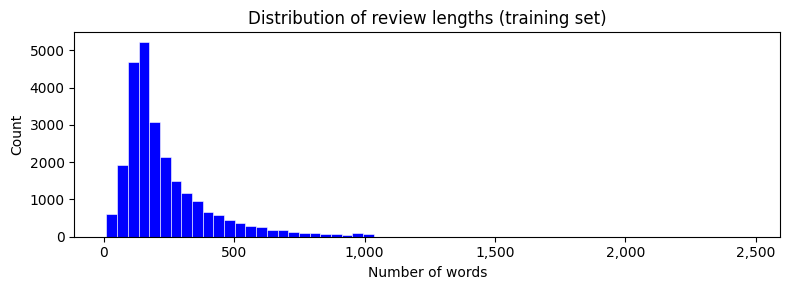

Median length : 174 words
Mean length   : 233 words
Max length    : 2,470 words


In [6]:
# Review length distribution
lengths = [len(t.split()) for t in train_texts]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lengths, bins=60, color="blue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Number of words")
ax.set_ylabel("Count")
ax.set_title("Distribution of review lengths (training set)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"Median length : {int(np.median(lengths)):,} words")
print(f"Mean length   : {int(np.mean(lengths)):,} words")
print(f"Max length    : {int(np.max(lengths)):,} words")

## Baseline: CountVectorizer + Logistic Regression

We start with the simplest possible pipeline: raw word counts fed into
a logistic regression classifier.  This will constitute our baseline.

In [ ]:
import nltk
from nltk.corpus import stopwords

# Define list of stop words
nltk.download('stopwords')
stop_words_en = stopwords.words('english')
#stop_words_en = []

In [ ]:
baseline_pipe = Pipeline([
    ("vec", CountVectorizer(max_features=20000, stop_words=stop_words_en)),
    ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)),
])

baseline_pipe.fit(train_texts, train_labels)
baseline_preds = baseline_pipe.predict(test_texts)
baseline_acc   = accuracy_score(test_labels, baseline_preds)

print(f"Baseline accuracy  : {baseline_acc:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    test_labels, baseline_preds,
    display_labels=["negative", "positive"],
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Baseline — Confusion Matrix")
plt.tight_layout()
plt.show()

## TF-IDF vs CountVectorizer

We now swap the vectoriser for `TfidfVectorizer` and keep everything else
identical.

TF-IDF up-weights terms that are frequent in a document but
rare across the corpus, and normalizes each document vector to unit L2 norm.


In [ ]:
tfidf_pipe = Pipeline([
    ("vec", TfidfVectorizer(max_features=20000, stop_words=stop_words_en)),
    ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)),
])

tfidf_pipe.fit(train_texts, train_labels)
tfidf_preds = tfidf_pipe.predict(test_texts)
tfidf_acc   = accuracy_score(test_labels, tfidf_preds)

print(f"CountVectorizer accuracy : {baseline_acc:.4f}")
print(f"TfidfVectorizer accuracy : {tfidf_acc:.4f}")
print(f"Accuracy difference      : {tfidf_acc - baseline_acc:+.4f}")

In [ ]:
# Side-by-side bar chart
labels  = ["CountVectorizer", "TfidfVectorizer"]
accs    = [baseline_acc, tfidf_acc]
colours = ["red", "blue"]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels, accs, color=colours, width=0.5, edgecolor="white")
ax.set_ylim(0.85, 0.93)
ax.set_ylabel("Test accuracy")
ax.set_title("CountVectorizer vs TF-IDF")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{acc:.4f}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()


## The effect of sublinear TF scaling

By default, `TfidfVectorizer` uses raw term frequency.  
Setting `sublinear_tf=True` replaces $tf$ with $1 + \log(tf)$, which
**compresses the scale** of very frequent terms.

| Raw TF | Sublinear TF |
|--------|-------------|
| 1      | 1.0         |
| 5      | 2.61        |
| 10     | 3.30        |
| 50     | 4.91        |
| 100    | 5.61        |

Intuition: the 100th occurrence of a word adds much less information
than the 1st.

In [ ]:
# Visualize transformation
tf_vals     = np.arange(1, 101)
sublinear   = 1 + np.log(tf_vals)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(tf_vals, tf_vals,   color="red", lw=2, label="Raw TF")
ax.plot(tf_vals, sublinear, color="blue", lw=2, label="Sublinear TF  [1 + log(tf)]")
ax.set_xlabel("Raw term frequency")
ax.set_ylabel("TF value used")
ax.set_title("Raw TF vs Sublinear TF")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
sublinear_pipe = Pipeline([
    ("vec", TfidfVectorizer(max_features=20_000, sublinear_tf=True)),
    ("clf", LogisticRegression(C=1.0, max_iter=1_000, random_state=SEED)),
])

sublinear_pipe.fit(train_texts, train_labels)
sublinear_preds = sublinear_pipe.predict(test_texts)
sublinear_acc   = accuracy_score(test_labels, sublinear_preds)

print(f"TF-IDF (standard)   : {tfidf_acc:.4f}")
print(f"TF-IDF (sublinear)  : {sublinear_acc:.4f}")
print(f"Accuracy difference : {sublinear_acc - tfidf_acc:+.4f}")

## Adding bigrams

N-grams treat sequences of $n$ consecutive tokens as single vocabulary units.  
`ngram_range=(1, 2)` includes both **unigrams** and **bigrams**.

Why might bigrams help in sentiment analysis?

| Unigrams only | With bigrams |
|---------------|--------------|
| "not"  +  "good" | "not good" as one feature |
| "highly" + "recommend" | "highly recommend" as one feature |

Note: bigrams greatly increase vocabulary size. To keep it under control, we can use `max_features`.

In [ ]:
bigram_pipe = Pipeline([
    ("vec", TfidfVectorizer(max_features=40000,
                            stop_words=stop_words_en,
                            sublinear_tf=True,
                            ngram_range=(1, 2))),
    ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)),
])

bigram_pipe.fit(train_texts, train_labels)
bigram_preds = bigram_pipe.predict(test_texts)
bigram_acc   = accuracy_score(test_labels, bigram_preds)

vocab_unigram = len(sublinear_pipe["vec"].vocabulary_)
vocab_bigram  = len(bigram_pipe["vec"].vocabulary_)

print(f"TF-IDF unigrams only : {sublinear_acc:.4f}  "
      f"(vocab size: {vocab_unigram:,})")
print(f"TF-IDF + bigrams     : {bigram_acc:.4f}  "
      f"(vocab size: {vocab_bigram:,})")
print(f"Accuracy difference : {bigram_acc - sublinear_acc:+.4f}")

In [ ]:
# Show the most common bigrams (by document frequency)
vec = bigram_pipe["vec"]
feature_names = vec.get_feature_names_out()
bigram_mask   = np.array(["_" not in f and " " in f for f in feature_names])
bigram_names  = feature_names[bigram_mask]

# Sum TF-IDF weights across training docs
TOP_N = 50
X_train_tfidf = vec.transform(train_texts)
bigram_scores  = np.asarray(X_train_tfidf[:, bigram_mask].sum(axis=0)).ravel()
top_bigram_idx = bigram_scores.argsort()[::-1][:TOP_N]

print("Top", TOP_N, "bigrams by aggregate TF-IDF weight:")
for i, idx in enumerate(top_bigram_idx, 1):
    print(f"  {i:2d}. {bigram_names[idx]:<30s}  {bigram_scores[idx]:.1f}")

## Interpretability: which words drive predictions?

One of the key advantages of TF-IDF + Logistic Regression over black-box
models is **transparency**.  The classifier learns a weight $w_j$ for every
feature $j$.  

- Large **positive** $w_j$: feature pushes toward *positive* sentiment  
- Large **negative** $w_j$: feature pushes toward *negative* sentiment


In [ ]:
# We use the sublinear TF-IDF pipeline (unigrams) for clarity
vec_interp = sublinear_pipe["vec"]
clf_interp = sublinear_pipe["clf"]

feature_names = vec_interp.get_feature_names_out()
coefs         = clf_interp.coef_[0]          # shape: (vocab_size,)

TOP_N = 20
top_pos_idx = coefs.argsort()[-TOP_N:][::-1]
top_neg_idx = coefs.argsort()[:TOP_N]

top_pos_words  = feature_names[top_pos_idx]
top_pos_coefs  = coefs[top_pos_idx]
top_neg_words  = feature_names[top_neg_idx]
top_neg_coefs  = coefs[top_neg_idx]

print(f"{'Top POSITIVE words':<30s}  {'Top NEGATIVE words'}")
print("-" * 60)
for pw, pc, nw, nc in zip(top_pos_words, top_pos_coefs,
                           top_neg_words, top_neg_coefs):
    print(f"  {pw:<25s} {pc:+.3f}    {nw:<25s} {nc:+.3f}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Positive words
axes[0].barh(top_pos_words[::-1], top_pos_coefs[::-1],
             color="green", edgecolor="white")
axes[0].set_title(f"Top {TOP_N} positive features", fontsize=12)
axes[0].set_xlabel("Logistic Regression coefficient")
axes[0].axvline(0, color="black", linewidth=0.8)

# Negative words
axes[1].barh(top_neg_words[::-1], top_neg_coefs[::-1],
             color="red", edgecolor="white")
axes[1].set_title(f"Top {TOP_N} negative features", fontsize=12)
axes[1].set_xlabel("Logistic Regression coefficient")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.suptitle("Most influential features: TF-IDF + Logistic Regression",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Inspect a prediction
sample_idx   = 42
sample_text  = test_texts[sample_idx]
sample_label = "positive" if test_labels[sample_idx] else "negative"
sample_pred  = "positive" if sublinear_pipe.predict([sample_text])[0] else "negative"
sample_prob  = sublinear_pipe.predict_proba([sample_text])[0]

print(f"True label  : {sample_label}")
print(f"Prediction  : {sample_pred}  "
      f"(P(pos) = {sample_prob[1]:.3f})")
print()
print("Review excerpt:")
print(sample_text[:500])
print()

# Which words from the review had the highest-weight features?
x_sample      = vec_interp.transform([sample_text])
nonzero_idx   = x_sample.nonzero()[1]
tfidf_vals    = x_sample[0, nonzero_idx].toarray().ravel()
coef_vals     = coefs[nonzero_idx]
contribution  = tfidf_vals * coef_vals           # TF-IDF × weight
words_present = feature_names[nonzero_idx]

# Sort by absolute contribution
order = np.abs(contribution).argsort()[::-1][:15]
print(f"{'Word':<20s}  {'TF-IDF':>8s}  {'Coef':>8s}  {'Contribution':>14s}")
print("-" * 55)
for i in order:
    print(f"  {words_present[i]:<18s}  {tfidf_vals[i]:>8.4f}  "
          f"{coef_vals[i]:>+8.3f}  {contribution[i]:>+14.4f}")

## Summary

Table with all results.


In [ ]:
results = pd.DataFrame([
    {"Configuration"           : "CountVectorizer (unigrams)",
     "max_features": 20_000, "ngram_range": "(1,1)",
     "sublinear_tf": False,  "Test accuracy": baseline_acc},
    {"Configuration"           : "TfidfVectorizer (unigrams)",
     "max_features": 20_000, "ngram_range": "(1,1)",
     "sublinear_tf": False,  "Test accuracy": tfidf_acc},
    {"Configuration"           : "TF-IDF + sublinear TF",
     "max_features": 20_000, "ngram_range": "(1,1)",
     "sublinear_tf": True,   "Test accuracy": sublinear_acc},
    {"Configuration"           : "TF-IDF + sublinear TF + bigrams",
     "max_features": 40_000, "ngram_range": "(1,2)",
     "sublinear_tf": True,   "Test accuracy": bigram_acc},
])

results["Test accuracy"] = results["Test accuracy"].map("{:.4f}".format)
results = results.set_index("Configuration")
results
